# Model Inference & Visualization

This notebook loads different trained models and runs them in the game environment with visual rendering.

**Models you can load:**
- Actor-Critic Basic: `models/actor-critic-basic/drone_policy_v*.pth`
- Actor-Critic GAE: `models/actor-critic-GAE/drone_policy_v*.pth`
- Actor-Critic PPO: `models/actor-critic-PPO/drone_policy_v*.pth`

In [3]:
import os
import torch
import torch.nn as nn
import numpy as np
from torch.distributions import Bernoulli
from delivery_drone.game.socket_client import DroneGameClient, DroneState

pygame 2.6.1 (SDL 2.28.4, Python 3.12.9)
Hello from the pygame community. https://www.pygame.org/contribute.html


In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cpu


## Network Architecture

All models use the same DroneGamerBoi architecture (3-layer MLP with LayerNorm).

In [5]:
def state_to_array(state, device='cpu'):
    """Convert DroneState dataclass to tensor"""
    data = np.array([
        state.drone_x,
        state.drone_y,
        state.drone_vx,
        state.drone_vy,
        state.drone_angle,
        state.drone_angular_vel,
        state.drone_fuel,
        state.platform_x,
        state.platform_y,
        state.distance_to_platform,
        state.dx_to_platform,
        state.dy_to_platform,
        state.speed,
        float(state.landed),
        float(state.crashed)
    ])
    return torch.tensor(data, dtype=torch.float32, device=device)


class DroneGamerBoi(nn.Module):
    def __init__(self, state_dim=15):
        super().__init__()
        
        self.network = nn.Sequential(
            nn.Linear(state_dim, 128),
            nn.LayerNorm(128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.LayerNorm(128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.LayerNorm(64),
            nn.ReLU(),
            nn.Linear(64, 3),
            nn.Sigmoid()
        )
        
    def forward(self, state):
        if isinstance(state, DroneState):
            state = state_to_array(state, device=device)
        return self.network(state)

## Load Model

**Available models:**
```
models/actor-critic-basic/drone_policy_v1.pth
models/actor-critic-basic/drone_policy_v2.pth
models/actor-critic-basic/drone_policy_v3.pth

models/actor-critic-GAE/drone_policy_v1.pth

models/actor-critic-PPO/drone_policy_v1.pth
models/actor-critic-PPO/drone_policy_v2.pth
```

In [6]:
# CONFIGURE THIS: Choose which model to load
MODEL_PATH = 'models/actor-critic-basic/drone_policy_v3.pth'

# Load the model
policy = DroneGamerBoi().to(device)
policy.load_state_dict(torch.load(MODEL_PATH, map_location=device))
policy.eval()  # Set to evaluation mode

print(f"✅ Loaded model: {MODEL_PATH}")
print(f"Policy on device: {next(policy.parameters()).device}")

✅ Loaded model: models/actor-critic-basic/drone_policy_v3.pth
Policy on device: cpu


## Connect to Game Server

**IMPORTANT:** Make sure the socket server is running:

```bash
cd delivery_drone
python socket_server.py --num-games 1 --render human
```

Use `--render human` to see the game visually!

In [7]:
client = DroneGameClient(port=5555)
client.connect()

print(f"Connected! Server has {client.num_games} game instance(s)")

Connecting to localhost:5555...
Connected to server at localhost:5555
Server has 1 game instance(s)
Connected! Server has 1 game instance(s)


## Run Inference Loop

This will run the model 20 times and track statistics.

**Parameters:**
- `num_episodes`: How many episodes to run (default: 20)
- `max_steps`: Maximum steps per episode (default: 500)
- `temperature`: Sampling temperature (0.0 = greedy, 1.0 = stochastic)
  - 0.0: Deterministic (always pick most likely action)
  - 0.3: Slightly stochastic (recommended for evaluation)
  - 1.0: Fully stochastic (exploration)

In [8]:
def run_inference_loop(client, policy, num_episodes=20, max_steps=500, temperature=0.3, game_id=0):
    """
    Run inference loop and collect statistics.
    
    Args:
        client: DroneGameClient instance
        policy: Trained policy network
        num_episodes: Number of episodes to run
        max_steps: Maximum steps per episode
        temperature: Sampling temperature (0=greedy, 1=stochastic)
        game_id: Which game instance to use
    
    Returns:
        Dictionary with statistics
    """
    policy.eval()
    
    results = []
    
    for episode in range(num_episodes):
        state = client.reset(game_id)
        steps = 0
        done = False
        
        while not done and steps < max_steps:
            with torch.no_grad():
                action_probs = policy(state)
            
            # Sample action based on temperature
            if temperature == 0:
                # Greedy (deterministic)
                action = (action_probs > 0.5).float()
            else:
                # Stochastic with temperature
                adjusted_probs = torch.pow(action_probs, 1.0 / temperature)
                adjusted_probs = adjusted_probs / (adjusted_probs + torch.pow(1 - action_probs, 1.0 / temperature))
                dist = Bernoulli(probs=adjusted_probs)
                action = dist.sample()
            
            next_state, _, done, _ = client.step({
                "main_thrust": int(action[0]),
                "left_thrust": int(action[1]),
                "right_thrust": int(action[2])
            }, game_id)
            
            state = next_state
            steps += 1
        
        # Record result
        results.append({
            'episode': episode + 1,
            'landed': state.landed,
            'crashed': state.crashed,
            'steps': steps,
            'final_fuel': state.drone_fuel,
            'final_distance': state.distance_to_platform
        })
        
        # Print result
        status = "✅ LANDED" if state.landed else "❌ CRASHED"
        print(f"Episode {episode + 1:2d}/{num_episodes}: {status} | Steps: {steps:3d} | Fuel: {state.drone_fuel:.1%} | Distance: {state.distance_to_platform:.3f}")
    
    # Compute statistics
    num_landings = sum(1 for r in results if r['landed'])
    success_rate = num_landings / num_episodes * 100
    avg_steps = sum(r['steps'] for r in results) / num_episodes
    avg_fuel = sum(r['final_fuel'] for r in results if r['landed']) / max(num_landings, 1)
    
    stats = {
        'success_rate': success_rate,
        'num_landings': num_landings,
        'num_episodes': num_episodes,
        'avg_steps': avg_steps,
        'avg_fuel_on_landing': avg_fuel,
        'results': results
    }
    
    print("\n" + "="*60)
    print(f"📊 SUMMARY STATISTICS")
    print("="*60)
    print(f"Success Rate:       {success_rate:.1f}% ({num_landings}/{num_episodes})")
    print(f"Avg Steps:          {avg_steps:.1f}")
    print(f"Avg Fuel (landings):{avg_fuel:.1%}")
    print("="*60)
    
    return stats

In [9]:
# Run 20 episodes with temperature=0.3 (slightly stochastic)
stats = run_inference_loop(
    client=client,
    policy=policy,
    num_episodes=20,
    max_steps=500,
    temperature=0.3,
    game_id=0
)

Episode  1/20: ✅ LANDED | Steps: 211 | Fuel: 59.1% | Distance: 0.065
Episode  2/20: ✅ LANDED | Steps: 217 | Fuel: 57.2% | Distance: 0.065
Episode  3/20: ✅ LANDED | Steps: 221 | Fuel: 57.6% | Distance: 0.064
Episode  4/20: ✅ LANDED | Steps: 196 | Fuel: 61.1% | Distance: 0.065
Episode  5/20: ✅ LANDED | Steps: 220 | Fuel: 58.7% | Distance: 0.064
Episode  6/20: ✅ LANDED | Steps: 201 | Fuel: 60.6% | Distance: 0.064
Episode  7/20: ✅ LANDED | Steps: 197 | Fuel: 62.6% | Distance: 0.064
Episode  8/20: ✅ LANDED | Steps: 207 | Fuel: 61.4% | Distance: 0.065
Episode  9/20: ✅ LANDED | Steps: 211 | Fuel: 59.3% | Distance: 0.064
Episode 10/20: ✅ LANDED | Steps: 182 | Fuel: 63.0% | Distance: 0.066
Episode 11/20: ✅ LANDED | Steps: 202 | Fuel: 60.5% | Distance: 0.063
Episode 12/20: ✅ LANDED | Steps:  39 | Fuel: 91.5% | Distance: 0.047
Episode 13/20: ✅ LANDED | Steps:  23 | Fuel: 95.0% | Distance: 0.054
Episode 14/20: ✅ LANDED | Steps: 196 | Fuel: 61.4% | Distance: 0.064
Episode 15/20: ✅ LANDED | Steps: 2

## Compare Multiple Models

Want to compare different models? Run this cell multiple times with different MODEL_PATH values.

In [ ]:
# Compare multiple models
models_to_compare = [
    'models/actor-critic-basic/drone_policy_v3.pth',
    'models/actor-critic-PPO/drone_policy_v2.pth',
    # Add more models here...
]

comparison_results = {}

for model_path in models_to_compare:
    print(f"\n{'='*60}")
    print(f"Testing: {model_path}")
    print(f"{'='*60}\n")
    
    # Load model
    policy = DroneGamerBoi().to(device)
    policy.load_state_dict(torch.load(model_path, map_location=device))
    policy.eval()
    
    # Run inference
    stats = run_inference_loop(
        client=client,
        policy=policy,
        num_episodes=20,
        max_steps=500,
        temperature=0.3,
        game_id=0
    )
    
    comparison_results[model_path] = stats

# Print comparison table
print("\n" + "="*80)
print("🏆 MODEL COMPARISON")
print("="*80)
print(f"{'Model':<50} {'Success Rate':<15} {'Avg Steps':<12}")
print("-"*80)
for model_path, stats in comparison_results.items():
    model_name = model_path.split('/')[-1]
    print(f"{model_name:<50} {stats['success_rate']:>6.1f}% ({stats['num_landings']:2d}/{stats['num_episodes']:2d})    {stats['avg_steps']:>8.1f}")
print("="*80)

## Visualize Episode

Run a single episode and track state history for visualization.

In [ ]:
import matplotlib.pyplot as plt

def run_and_visualize_episode(client, policy, max_steps=500, temperature=0.3, game_id=0):
    """
    Run one episode and visualize state trajectories.
    """
    policy.eval()
    state = client.reset(game_id)
    
    # Track history
    history = {
        'step': [],
        'drone_x': [],
        'drone_y': [],
        'distance': [],
        'speed': [],
        'angle': [],
        'fuel': [],
    }
    
    steps = 0
    done = False
    
    while not done and steps < max_steps:
        # Store state
        history['step'].append(steps)
        history['drone_x'].append(state.drone_x)
        history['drone_y'].append(state.drone_y)
        history['distance'].append(state.distance_to_platform)
        history['speed'].append(state.speed)
        history['angle'].append(state.drone_angle)
        history['fuel'].append(state.drone_fuel)
        
        # Get action
        with torch.no_grad():
            action_probs = policy(state)
        
        if temperature == 0:
            action = (action_probs > 0.5).float()
        else:
            adjusted_probs = torch.pow(action_probs, 1.0 / temperature)
            adjusted_probs = adjusted_probs / (adjusted_probs + torch.pow(1 - action_probs, 1.0 / temperature))
            dist = Bernoulli(probs=adjusted_probs)
            action = dist.sample()
        
        next_state, _, done, _ = client.step({
            "main_thrust": int(action[0]),
            "left_thrust": int(action[1]),
            "right_thrust": int(action[2])
        }, game_id)
        
        state = next_state
        steps += 1
    
    # Plot trajectories
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    
    # Distance to platform
    axes[0, 0].plot(history['step'], history['distance'], linewidth=2, color='blue')
    axes[0, 0].set_xlabel('Steps')
    axes[0, 0].set_ylabel('Distance to Platform')
    axes[0, 0].set_title('Distance Over Time')
    axes[0, 0].grid(True, alpha=0.3)
    
    # Speed
    axes[0, 1].plot(history['step'], history['speed'], linewidth=2, color='green')
    axes[0, 1].axhline(y=0.3, color='red', linestyle='--', label='Landing threshold')
    axes[0, 1].set_xlabel('Steps')
    axes[0, 1].set_ylabel('Speed')
    axes[0, 1].set_title('Speed Over Time')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # Angle
    axes[0, 2].plot(history['step'], history['angle'], linewidth=2, color='orange')
    axes[0, 2].axhline(y=0.111, color='red', linestyle='--', label='Landing threshold')
    axes[0, 2].axhline(y=-0.111, color='red', linestyle='--')
    axes[0, 2].set_xlabel('Steps')
    axes[0, 2].set_ylabel('Angle (normalized)')
    axes[0, 2].set_title('Angle Over Time')
    axes[0, 2].legend()
    axes[0, 2].grid(True, alpha=0.3)
    
    # Fuel
    axes[1, 0].plot(history['step'], history['fuel'], linewidth=2, color='purple')
    axes[1, 0].set_xlabel('Steps')
    axes[1, 0].set_ylabel('Fuel Remaining')
    axes[1, 0].set_title('Fuel Over Time')
    axes[1, 0].grid(True, alpha=0.3)
    
    # 2D Position trajectory
    axes[1, 1].plot(history['drone_x'], history['drone_y'], linewidth=2, marker='o', markersize=3)
    axes[1, 1].scatter([state.platform_x], [state.platform_y], color='red', s=200, marker='s', label='Platform')
    axes[1, 1].scatter([history['drone_x'][0]], [history['drone_y'][0]], color='green', s=100, marker='o', label='Start')
    axes[1, 1].scatter([history['drone_x'][-1]], [history['drone_y'][-1]], color='blue', s=100, marker='x', label='End')
    axes[1, 1].set_xlabel('X Position')
    axes[1, 1].set_ylabel('Y Position')
    axes[1, 1].set_title('2D Trajectory')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    axes[1, 1].set_aspect('equal')
    
    # Summary text
    status = "✅ LANDED" if state.landed else "❌ CRASHED"
    summary = f"{status}\n\nSteps: {steps}\nFinal Fuel: {state.drone_fuel:.1%}\nFinal Distance: {state.distance_to_platform:.3f}"
    axes[1, 2].text(0.5, 0.5, summary, ha='center', va='center', fontsize=14, 
                   bbox=dict(boxstyle='round', facecolor='lightgreen' if state.landed else 'lightcoral', alpha=0.5))
    axes[1, 2].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    return history

In [ ]:
# Visualize a single episode
history = run_and_visualize_episode(
    client=client,
    policy=policy,
    max_steps=500,
    temperature=0.3,
    game_id=0
)

## Cleanup

Close the connection when done.

In [15]:
client.close()  # Uncomment when done

Disconnected from server


## Create Learning Signals Comparison Diagram

This diagram shows the dramatic difference in learning signal frequency between REINFORCE and Actor-Critic.

✅ Diagram saved: blogs/RL-2-Actor-critic/gifs/learning_signals_comparison.png


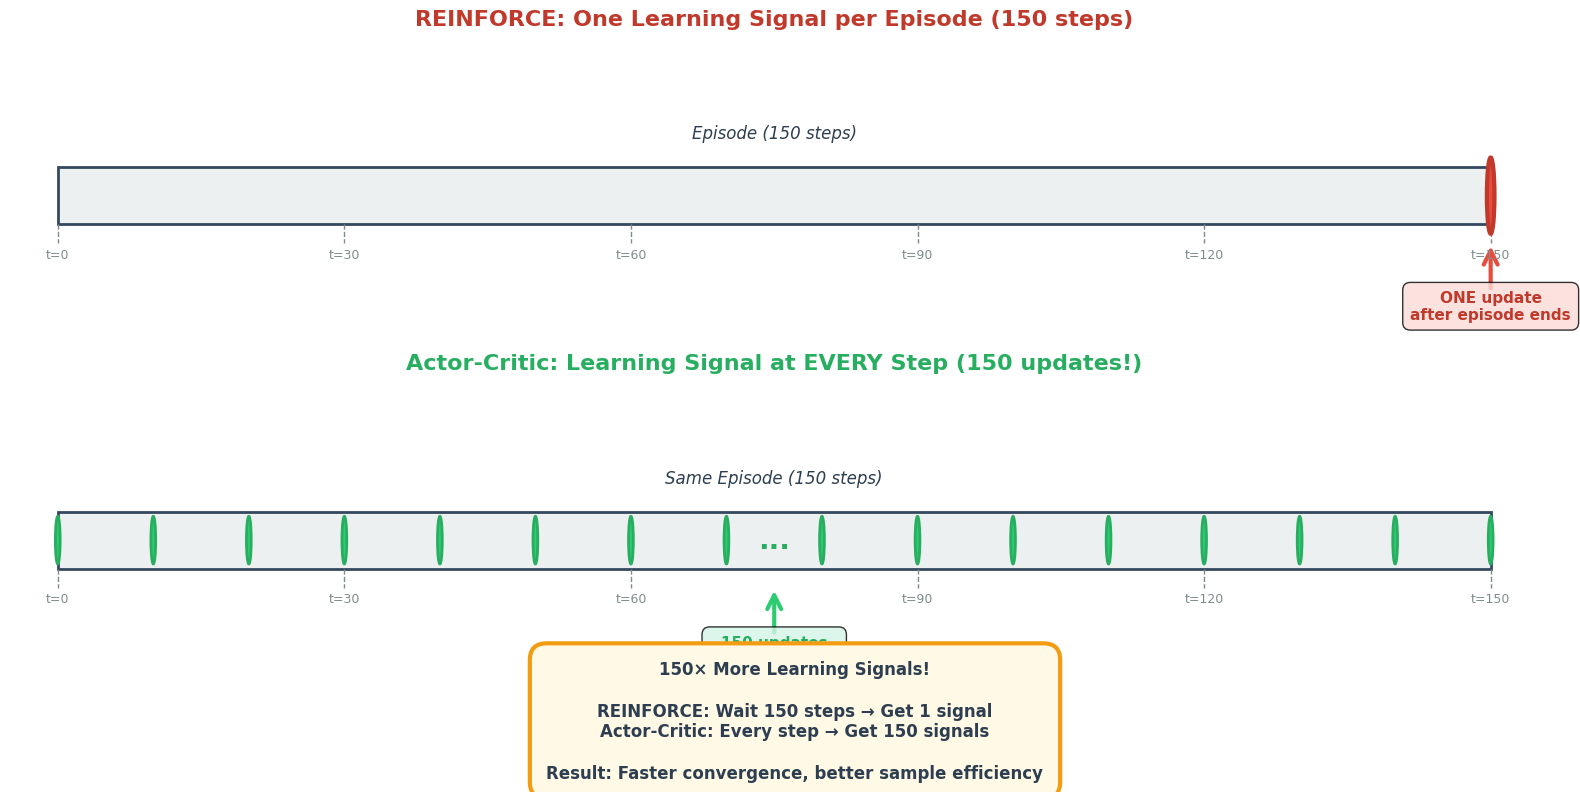

In [1]:
"""
Create a visual comparison of learning signal frequency:
REINFORCE vs Actor-Critic

Shows how Actor-Critic gets 150x more learning signals per iteration.
"""

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, Rectangle, FancyArrowPatch, Circle
import numpy as np

# Create figure with two panels (REINFORCE on top, Actor-Critic on bottom)
fig, (ax_reinforce, ax_ac) = plt.subplots(2, 1, figsize=(16, 8))

# ============================================================================
# PANEL 1: REINFORCE (One signal per episode)
# ============================================================================

ax_reinforce.set_xlim(0, 160)
ax_reinforce.set_ylim(0, 3)
ax_reinforce.axis('off')
ax_reinforce.set_title('REINFORCE: One Learning Signal per Episode (150 steps)',
                       fontsize=16, fontweight='bold', pad=20, color='#c0392b')

# Draw episode timeline (150 steps represented as a long bar)
episode_bar = Rectangle((5, 1.2), 150, 0.6,
                        facecolor='#ecf0f1', edgecolor='#34495e', linewidth=2)
ax_reinforce.add_patch(episode_bar)

# Add step markers
for i in range(0, 151, 30):
    x_pos = 5 + i
    ax_reinforce.plot([x_pos, x_pos], [1.2, 1.0], color='#7f8c8d', linewidth=1, linestyle='--')
    ax_reinforce.text(x_pos, 0.85, f't={i}', ha='center', fontsize=9, color='#7f8c8d')

# Add "Episode" label
ax_reinforce.text(80, 2.1, 'Episode (150 steps)', ha='center', fontsize=12,
                 style='italic', color='#2c3e50')

# Draw SINGLE learning signal at the end
signal_x = 155
signal_circle = Circle((signal_x, 1.5), 0.4, facecolor='#e74c3c', edgecolor='#c0392b',
                       linewidth=3, zorder=10)
ax_reinforce.add_patch(signal_circle)
ax_reinforce.text(signal_x, 1.5, '1', ha='center', va='center', fontsize=14,
                 fontweight='bold', color='white')

# Arrow pointing to signal
arrow = FancyArrowPatch((155, 0.5), (155, 1.0),
                       arrowstyle='->', mutation_scale=25,
                       linewidth=3, color='#e74c3c')
ax_reinforce.add_patch(arrow)
ax_reinforce.text(155, 0.2, 'ONE update\nafter episode ends', ha='center',
                 fontsize=11, color='#c0392b', fontweight='bold',
                 bbox=dict(boxstyle='round,pad=0.5', facecolor='#fadbd8', alpha=0.8))

# ============================================================================
# PANEL 2: ACTOR-CRITIC (Signal at EVERY step)
# ============================================================================

ax_ac.set_xlim(0, 160)
ax_ac.set_ylim(0, 3)
ax_ac.axis('off')
ax_ac.set_title('Actor-Critic: Learning Signal at EVERY Step (150 updates!)',
               fontsize=16, fontweight='bold', pad=20, color='#27ae60')

# Draw the same 150-step timeline
episode_bar_ac = Rectangle((5, 1.2), 150, 0.6,
                          facecolor='#ecf0f1', edgecolor='#34495e', linewidth=2)
ax_ac.add_patch(episode_bar_ac)

# Add step markers
for i in range(0, 151, 30):
    x_pos = 5 + i
    ax_ac.plot([x_pos, x_pos], [1.2, 1.0], color='#7f8c8d', linewidth=1, linestyle='--')
    ax_ac.text(x_pos, 0.85, f't={i}', ha='center', fontsize=9, color='#7f8c8d')

# Add "Episode" label
ax_ac.text(80, 2.1, 'Same Episode (150 steps)', ha='center', fontsize=12,
          style='italic', color='#2c3e50')

# Draw MANY learning signals (show every 10th to avoid clutter)
signal_positions = list(range(5, 156, 10))  # Every 10th step
for i, x_pos in enumerate(signal_positions):
    signal_circle = Circle((x_pos, 1.5), 0.25, facecolor='#2ecc71',
                          edgecolor='#27ae60', linewidth=2, zorder=10)
    ax_ac.add_patch(signal_circle)

    # Add number to first few signals
    if i < 3:
        ax_ac.text(x_pos, 1.5, str(i+1), ha='center', va='center',
                  fontsize=8, fontweight='bold', color='white')

# Add "..." to indicate continuation
ax_ac.text(80, 1.5, '...', ha='center', va='center', fontsize=20,
          fontweight='bold', color='#27ae60')

# Arrow pointing to signals
arrow_ac = FancyArrowPatch((80, 0.5), (80, 1.0),
                          arrowstyle='->', mutation_scale=25,
                          linewidth=3, color='#2ecc71')
ax_ac.add_patch(arrow_ac)
ax_ac.text(80, 0.2, '150 updates\n(one per step!)', ha='center',
          fontsize=11, color='#27ae60', fontweight='bold',
          bbox=dict(boxstyle='round,pad=0.5', facecolor='#d5f4e6', alpha=0.8))

# ============================================================================
# Add summary comparison box
# ============================================================================

# Create a summary text box
summary_text = (
    "150× More Learning Signals!\n\n"
    "REINFORCE: Wait 150 steps → Get 1 signal\n"
    "Actor-Critic: Every step → Get 150 signals\n\n"
    "Result: Faster convergence, better sample efficiency"
)

fig.text(0.5, 0.02, summary_text, ha='center', fontsize=12,
         bbox=dict(boxstyle='round,pad=1', facecolor='#fff9e6',
                  edgecolor='#f39c12', linewidth=3),
         color='#2c3e50', fontweight='bold')

plt.tight_layout(rect=[0, 0.12, 1, 1])
plt.savefig('blogs/RL-2-Actor-critic/gifs/learning_signals_comparison.png',
            dpi=300, bbox_inches='tight')
print("✅ Diagram saved: blogs/RL-2-Actor-critic/gifs/learning_signals_comparison.png")

plt.show()

/tmp/ipykernel_161234/1815724593.py:53: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_161234/1815724593.py:53: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_161234/1815724593.py:54: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.savefig('blogs/RL-2-Actor-critic/gifs/critic_loss_comparison.png', dpi=300, bbox_inches='tight')
/tmp/ipykernel_161234/1815724593.py:54: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig('blogs/RL-2-Actor-critic/gifs/critic_loss_comparison.png', dpi=300, bbox_inches='tight')


✅ Saved: blogs/RL-2-Actor-critic/gifs/critic_loss_comparison.png


/home/vedantjumle/miniconda3/envs/torch/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/vedantjumle/miniconda3/envs/torch/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


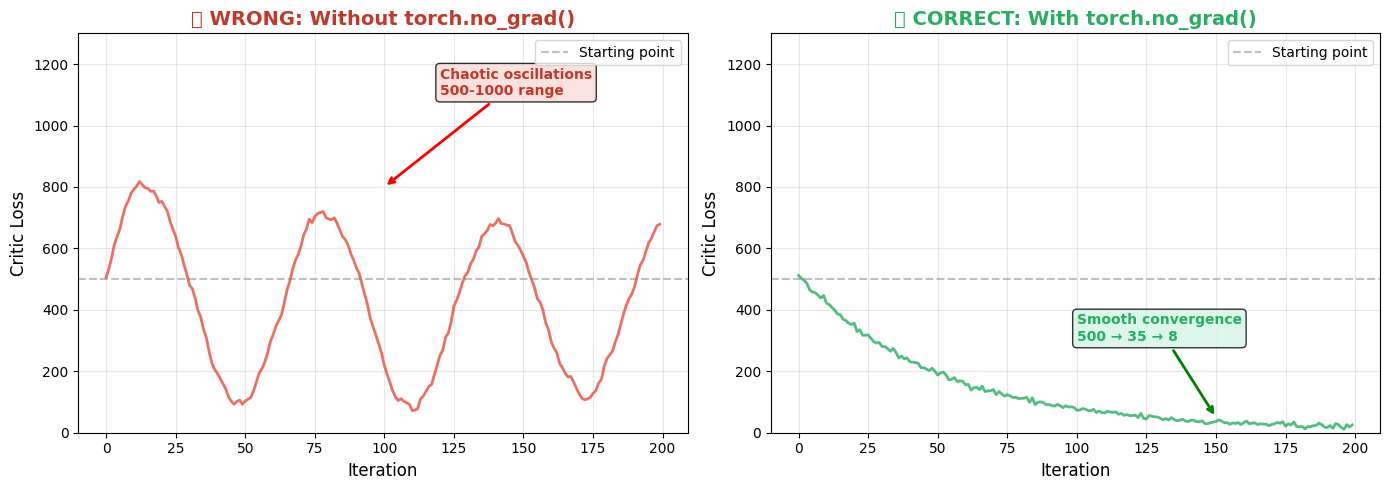

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# Simulate critic loss behavior
iterations = np.arange(0, 200)

# WRONG version: Oscillating wildly
np.random.seed(42)
buggy_loss = 500 + 300 * np.sin(iterations / 10) + 200 * np.random.randn(200).cumsum() / 20
buggy_loss = np.clip(buggy_loss, 50, 1200)  # Keep in reasonable range

# CORRECT version: Smooth decrease
fixed_loss = 500 * np.exp(-iterations / 50) + 10 + 5 * np.random.randn(200)
fixed_loss = np.clip(fixed_loss, 5, 600)

# Create side-by-side plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: WRONG (oscillating)
ax1.plot(iterations, buggy_loss, linewidth=2, color='#e74c3c', alpha=0.8)
ax1.set_xlabel('Iteration', fontsize=12)
ax1.set_ylabel('Critic Loss', fontsize=12)
ax1.set_title('❌ WRONG: Without torch.no_grad()', fontsize=14, fontweight='bold', color='#c0392b')
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, 1300)
ax1.axhline(y=500, color='gray', linestyle='--', alpha=0.5, label='Starting point')
ax1.legend()

# Add annotation showing oscillation
ax1.annotate('Chaotic oscillations\n500-1000 range', 
             xy=(100, 800), xytext=(120, 1100),
             arrowprops=dict(arrowstyle='->', color='red', lw=2),
             fontsize=10, color='#c0392b', fontweight='bold',
             bbox=dict(boxstyle='round', facecolor='#fadbd8', alpha=0.8))

# Right: CORRECT (smooth)
ax2.plot(iterations, fixed_loss, linewidth=2, color='#27ae60', alpha=0.8)
ax2.set_xlabel('Iteration', fontsize=12)
ax2.set_ylabel('Critic Loss', fontsize=12)
ax2.set_title('✅ CORRECT: With torch.no_grad()', fontsize=14, fontweight='bold', color='#27ae60')
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, 1300)
ax2.axhline(y=500, color='gray', linestyle='--', alpha=0.5, label='Starting point')
ax2.legend()

# Add annotation showing convergence
ax2.annotate('Smooth convergence\n500 → 35 → 8', 
             xy=(150, 50), xytext=(100, 300),
             arrowprops=dict(arrowstyle='->', color='green', lw=2),
             fontsize=10, color='#27ae60', fontweight='bold',
             bbox=dict(boxstyle='round', facecolor='#d5f4e6', alpha=0.8))

plt.tight_layout()
plt.savefig('blogs/RL-2-Actor-critic/gifs/critic_loss_comparison.png', dpi=300, bbox_inches='tight')
print("✅ Saved: blogs/RL-2-Actor-critic/gifs/critic_loss_comparison.png")
plt.show()
